### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns

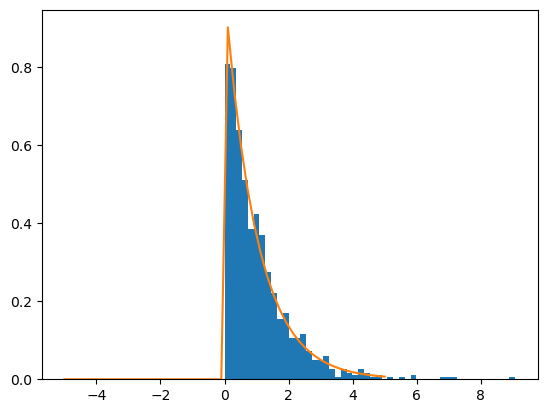

1.03650371387151
0.00037065433063414473
0.9902078146066298


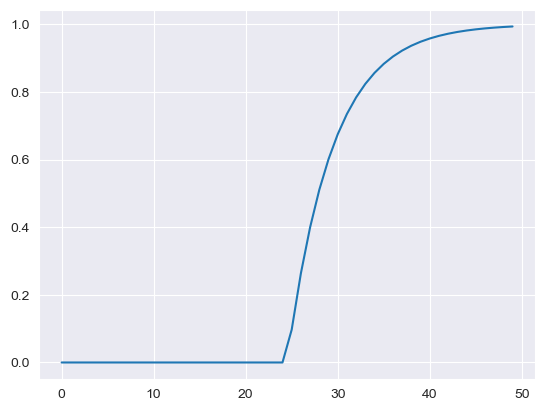

In [2]:
dist = sp.stats.gamma(1) # standard gamma distribution 
sample = dist.rvs(size=1000) # "random variate sample"
plt.hist(sample, bins=50, density=True, label='normalized histogram') 
x = np.linspace(-5, 5)
plt.plot(x, dist.pdf(x), label='PDF')
plt.show()
shape, loc ,scale = sp.stats.gamma.fit(sample)
print(shape)
print(loc)
print(scale)
sns.set_style(style="darkgrid")
sns.lineplot(dist.cdf(x))
plt.show()

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.] [15.9318391  18.16987298 22.70694496 28.32735027 33.52510586 36.9074773
 37.5681609  35.33012702 30.79305504 25.17264973 19.97489414 16.5925227 ]


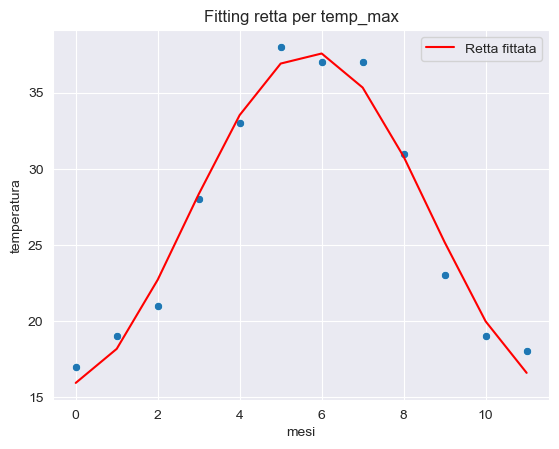

1.0458509759751113
1.1946466156624653
0.9766752925627983


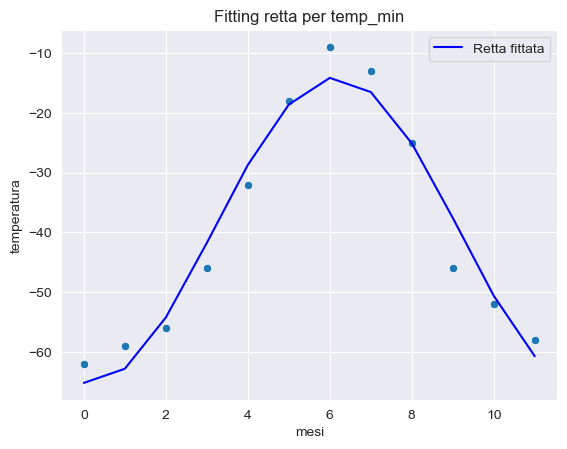

1.0458509759751113
1.1946466156624653
0.9570699008184621


In [16]:
import numpy as np
import scipy as sp
import seaborn as sns
import math
import matplotlib.pyplot as plt

def cosine(x, offset, amp, phase):
    return offset + amp * np.cos((2 * np.pi / 12) * (x - phase))

temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
n_temp_max = temp_max.size


sns.set_style(style="darkgrid")
sns.scatterplot(temp_max)
x = np.linspace(start=0,stop=len(temp_max)-1,endpoint=True, num=12)


params, _ = sp.optimize.curve_fit(f=cosine , xdata=x ,ydata=temp_max)
offset, amp, phase = params


y_fit_max = cosine(x, offset, amp, phase)

print(x, y_fit_max)
# plot

plt.plot(x, y_fit_max, label="Retta fittata", color="red")
plt.legend()
plt.xlabel("mesi")
plt.ylabel("temperatura")
plt.title("Fitting retta per temp_max")
plt.show()


# MAE e RMSE per lineare e Rquadro
MAE_max = sum(abs(temp_max-y_fit_max))/n_temp_max
RMSE_max = math.sqrt(sum((temp_max-y_fit_max)**2)/n_temp_max)
ss_tot = np.sum((temp_max - np.mean(temp_max))**2)
ss_res = np.sum((temp_max - y_fit_max)**2)
r2 = 1 - ss_res / ss_tot
print(MAE_max)
print(RMSE_max)
print(r2)



# ora per temp min
n_temp_min = temp_min.size
sns.scatterplot(temp_min)
x = np.linspace(start=0,stop=len(temp_min)-1,endpoint=True, num=12)


params, _ = sp.optimize.curve_fit(f=cosine , xdata=x ,ydata=temp_min)
offset, amp, phase = params


y_fit_min = cosine(x, offset, amp, phase)


# plot

plt.plot(x, y_fit_min, label="Retta fittata", color="blue")
plt.legend()
plt.xlabel("mesi")
plt.ylabel("temperatura")
plt.title("Fitting retta per temp_min")
plt.show()


# MAE e RMSE per lineare e Rquadro
MAE = sum(abs(temp_min-y_fit_min))/n_temp_min
RMSE = math.sqrt(sum((temp_min-y_fit_min)**2)/n_temp_min)
ss_tot = np.sum((temp_min - np.mean(temp_min))**2)
ss_res = np.sum((temp_min - y_fit_min)**2)
r2 = 1 - ss_res / ss_tot
print(MAE_max)
print(RMSE_max)
print(r2)


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

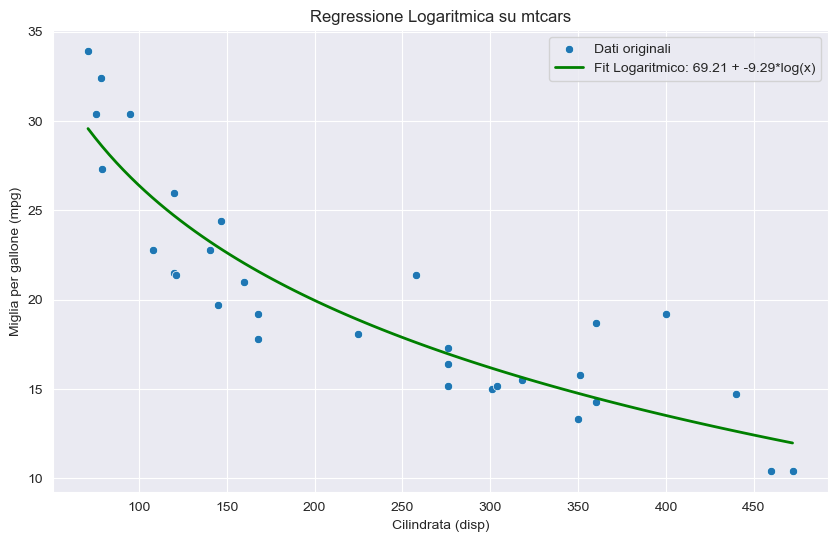

MAE  : 2.0629
RMSE : 2.4967
R^2  : 0.8229


In [51]:
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

def logaritm(x, a, b):
    return a + b * np.log(x)

df.sort_values(by="disp", inplace=True)
x = df.disp.values
y = df.mpg.values

params, _ = sp.optimize.curve_fit(f=logaritm, xdata=x, ydata=y)
a, b = params

y_fit = logaritm(x, a, b) 

# plot stuff
x_range = np.linspace(x.min(), x.max(), 100)
y_plot = logaritm(x_range, a, b)


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="disp", y="mpg", label="Dati originali")
plt.plot(x_range, y_plot, label=f"Fit Logaritmico: {a:.2f} + {b:.2f}*log(x)", color="green", linewidth=2)
plt.legend()
plt.xlabel("Cilindrata (disp)")
plt.ylabel("Miglia per gallone (mpg)")
plt.title("Regressione Logaritmica su mtcars")
plt.show()

MAE = np.mean(np.abs(y - y_fit))
RMSE = np.sqrt(np.mean((y - y_fit)**2))
r2 = 1 - (np.sum((y - y_fit)**2) / np.sum((y - np.mean(y))**2))

print(f"MAE  : {MAE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"R^2  : {r2:.4f}")